# Machine Learning Tasks: Regression, Classification & Clustering (Package-based Datasets)

This notebook demonstrates:
- Regression, Classification, and Clustering tasks
- Algorithms with and without API
- Datasets loaded directly from Python packages (no external URLs)

Datasets used:
- Regression: sklearn.datasets.load_diabetes
- Classification: sklearn.datasets.load_breast_cancer
- Clustering: sklearn.datasets.make_blobs

## Import Required Libraries

In [1]:
# Numerical computation
import numpy as np

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loaders
from sklearn.datasets import load_diabetes, load_breast_cancer, make_blobs

# Model utilities
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

# Classification model
from sklearn.svm import SVC

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, silhouette_score

# Feature scaling
from sklearn.preprocessing import StandardScaler

## Regression Task – Diabetes Dataset (EDA)

In [2]:
# Load Diabetes dataset from sklearn
diabetes = load_diabetes()

# Convert to DataFrame
df_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_reg['target'] = diabetes.target

# Preview dataset
df_reg.head()

# Dataset information
df_reg.info()

# Statistical summary
df_reg.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


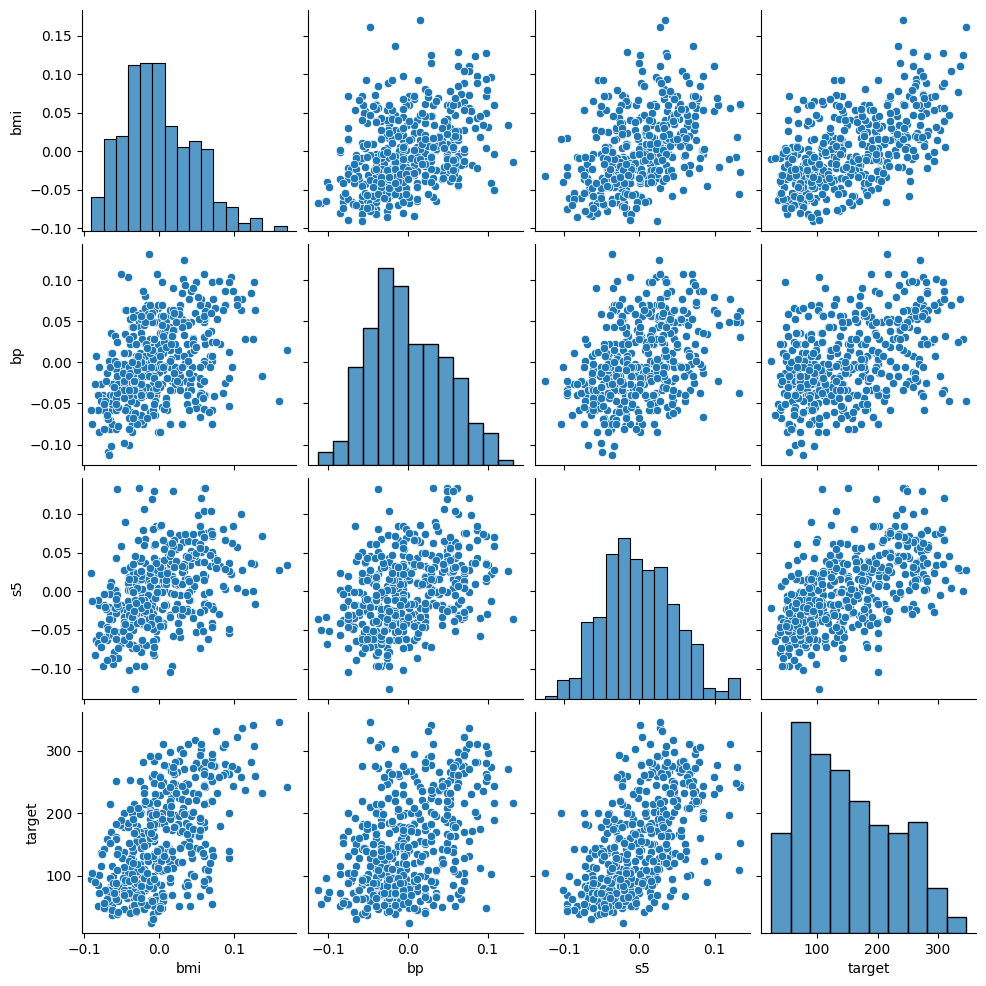

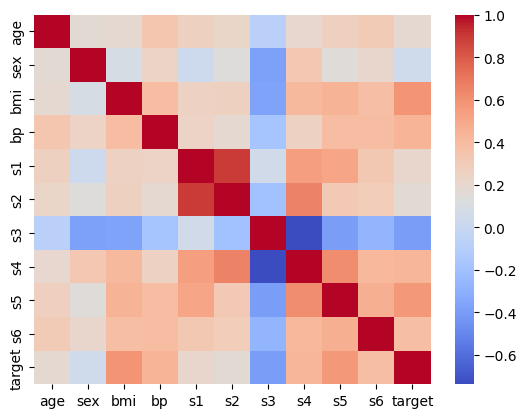

In [3]:
# Pairplot of selected features
sns.pairplot(df_reg[['bmi', 'bp', 's5', 'target']])
plt.show()

# Correlation heatmap
sns.heatmap(df_reg.corr(), cmap='coolwarm')
plt.show()

## Regression Comparison: Linear Regression vs Ridge Regression

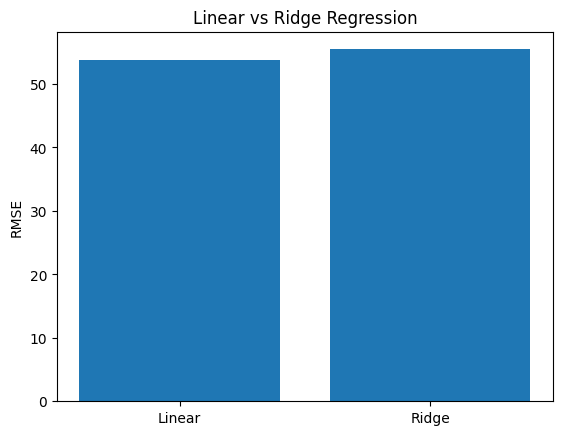

In [4]:
# Separate features and target
X = df_reg.drop('target', axis=1)
y = df_reg['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr = lr.predict(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_ridge = ridge.predict(X_test)

# RMSE values
rmse_lr = np.sqrt(mean_squared_error(y_test, y_lr))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_ridge))

# RMSE comparison plot
plt.bar(['Linear', 'Ridge'], [rmse_lr, rmse_ridge])
plt.ylabel('RMSE')
plt.title('Linear vs Ridge Regression')
plt.show()

## Classification Task – Breast Cancer Dataset

In [5]:
# Load Breast Cancer dataset
cancer = load_breast_cancer()

# Convert to DataFrame
df_clf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_clf['target'] = cancer.target

# Class distribution
df_clf['target'].value_counts()

,count
target,
1,357
0,212


## Classification Comparison: Logistic Regression vs SVM

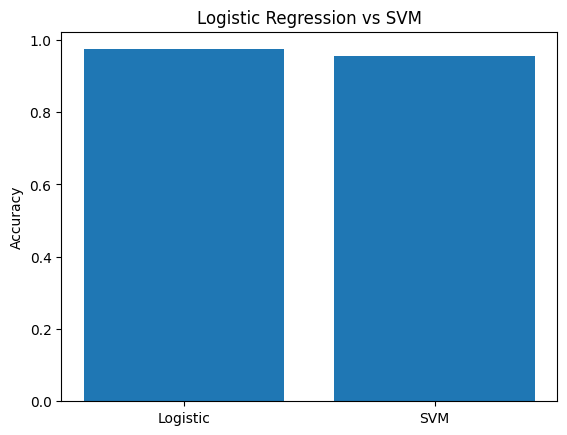

In [6]:
# Separate features and labels
X = df_clf.drop('target', axis=1)
y = df_clf['target']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)
y_log = log_reg.predict(X_test)

# Support Vector Machine
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_svm = svm.predict(X_test)

# Accuracy values
acc_log = accuracy_score(y_test, y_log)
acc_svm = accuracy_score(y_test, y_svm)

# Accuracy comparison plot
plt.bar(['Logistic', 'SVM'], [acc_log, acc_svm])
plt.ylabel('Accuracy')
plt.title('Logistic Regression vs SVM')
plt.show()

## Clustering Task – Synthetic Dataset

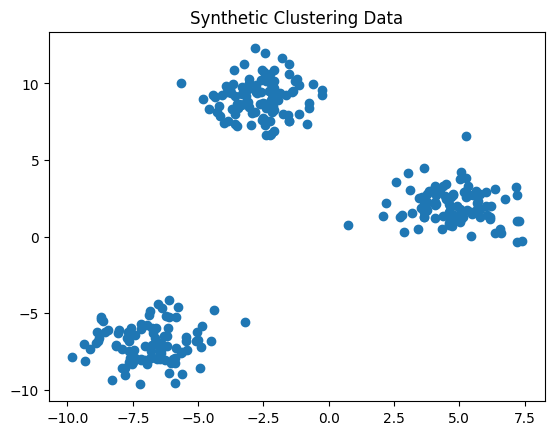

In [7]:
# Generate synthetic clustering data using make_blobs
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

# Scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.title('Synthetic Clustering Data')
plt.show()

## Clustering Comparison: KMeans vs Agglomerative

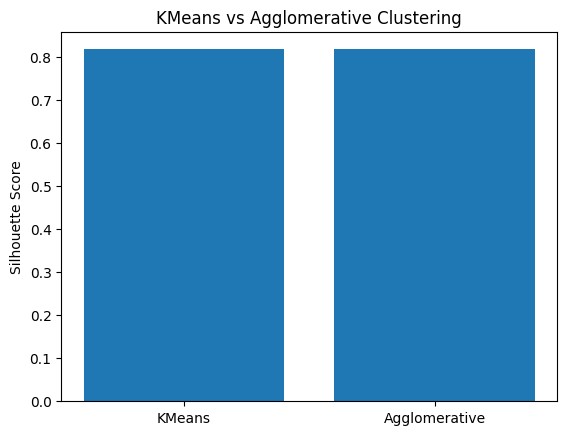

In [8]:
# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X)
sil_km = silhouette_score(X, labels_km)

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X)
sil_agg = silhouette_score(X, labels_agg)

# Silhouette comparison plot
plt.bar(['KMeans', 'Agglomerative'], [sil_km, sil_agg])
plt.ylabel('Silhouette Score')
plt.title('KMeans vs Agglomerative Clustering')
plt.show()

## Final Interpretation

- Package-based datasets improve reproducibility and offline usage.
- Ridge Regression stabilizes coefficients compared to Linear Regression.
- SVM focuses on margin maximization, Logistic Regression on probability estimation.
- KMeans is centroid-based; Agglomerative is hierarchy-based.

📌 Always choose algorithms based on **data characteristics and evaluation plots**.